In [1]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
mnist_dataset = tfds.load("mnist")
iris_dataset = tfds.load("iris")

### Load the datasets
This cell loads the MNIST and Iris datasets with TensorFlow Datasets. They are used in later cells for examples on array handling, classification, and image inspection.

In [3]:
features = np.array([ex['features'] for ex in iris_dataset["train"]])
labels = np.array([ex['label'] for ex in iris_dataset["train"]])

### Extract features and labels
Here the Iris examples are converted into NumPy arrays. `features` holds the four measurements for each flower, and `labels` stores the class index for each example.

In [4]:
features.shape, features.ndim, features.size, features.dtype

((150, 4), 2, 600, dtype('float32'))

### Inspect the feature array
This quick check shows the shape, number of dimensions, size, and data type of the feature matrix so you can understand how the data is stored.

In [5]:
np.argmax(features, axis=0), np.mean(features, axis=0), np.std(features, axis=0), np.max(features, axis=0), np.min(features, axis=0), np.min(features, axis=0)

(array([ 21,  47, 122, 105]),
 array([5.843335 , 3.0539997, 3.7586653, 1.1986668], dtype=float32),
 array([0.8253011 , 0.43214667, 1.758529  , 0.76061267], dtype=float32),
 array([7.9, 4.4, 6.9, 2.5], dtype=float32),
 array([4.3, 2. , 1. , 0.1], dtype=float32),
 array([4.3, 2. , 1. , 0.1], dtype=float32))

In [ ]:
test = np.random.rand(100, 2)
test[np.argsort(test[:, 0])]

(array([[0.00474616, 0.03715898],
        [0.02643764, 0.30851481],
        [0.0726115 , 0.86711532],
        [0.0740175 , 0.09153552],
        [0.08397789, 0.1141881 ],
        [0.08873199, 0.87575881],
        [0.10980326, 0.50864875],
        [0.11069012, 0.65450196],
        [0.11327351, 0.14437991],
        [0.11357958, 0.71058409],
        [0.11415019, 0.30571611],
        [0.14228273, 0.51056199],
        [0.15127779, 0.92181374],
        [0.16706843, 0.94181936],
        [0.17654445, 0.24393849],
        [0.20626173, 0.47138243],
        [0.21397875, 0.61225394],
        [0.22200627, 0.63932957],
        [0.22484717, 0.01945271],
        [0.23834497, 0.50022648],
        [0.25410005, 0.26946186],
        [0.25427475, 0.87321971],
        [0.26705606, 0.5164023 ],
        [0.27870876, 0.6943145 ],
        [0.28632485, 0.40276309],
        [0.30621378, 0.34868261],
        [0.34421279, 0.74746322],
        [0.35795868, 0.31232677],
        [0.35835947, 0.83849157],
        [0.363

### Sort a random 2D array by one column
This creates a random matrix and uses `np.argsort` on the first column so the rows can be viewed in ascending order by that value.

In [19]:
min_values_per_column = np.min(features, axis=0)
max_values_per_column = np.max(features, axis=0)
normalized_features = (features - min_values_per_column) / (max_values_per_column - min_values_per_column)
normalized_features

array([[0.22222215, 0.5833334 , 0.08474576, 0.04166666],
       [0.94444436, 0.41666666, 0.86440676, 0.9166666 ],
       [0.3888888 , 0.3333333 , 0.59322035, 0.49999994],
       [0.6944445 , 0.5       , 0.8305085 , 0.9166666 ],
       [0.2499999 , 0.5833334 , 0.0677966 , 0.04166666],
       [0.36111104, 0.37500003, 0.44067794, 0.49999994],
       [0.33333328, 0.24999996, 0.5762712 , 0.4583333 ],
       [0.33333328, 0.1666667 , 0.45762712, 0.37499997],
       [0.08333325, 0.5833334 , 0.0677966 , 0.08333334],
       [0.94444436, 0.3333333 , 0.96610165, 0.7916666 ],
       [0.74999994, 0.5       , 0.6271186 , 0.5416666 ],
       [0.08333325, 0.5       , 0.0677966 , 0.04166666],
       [0.61111104, 0.41666666, 0.71186435, 0.7916666 ],
       [0.33333328, 0.91666657, 0.0677966 , 0.04166666],
       [0.30555552, 0.7916667 , 0.05084745, 0.125     ],
       [0.1944444 , 0.625     , 0.05084745, 0.08333334],
       [0.22222215, 0.74999994, 0.08474576, 0.08333334],
       [0.1388889 , 0.41666666,

### Normalize the features
This rescales every feature into the range from 0 to 1 using the column-wise minimum and maximum values.

In [58]:
random_matrix = np.arange(12).reshape(3, 4)
max = random_matrix > 6
masked_matrix = random_matrix
masked_matrix[max] = -1

random_matrix[:2, :2], masked_matrix

(array([[0, 1],
        [4, 5]]),
 array([[ 0,  1,  2,  3],
        [ 4,  5,  6, -1],
        [-1, -1, -1, -1]]))

### Mask values in a matrix
This cell builds a boolean mask and uses it to replace values greater than 6 with `-1`. It also shows how slicing returns a view of the matrix.

In [60]:
single_row = random_matrix[0]
single_row[0] = 99
random_matrix, single_row

(array([[99,  1,  2,  3],
        [ 4,  5,  6, -1],
        [-1, -1, -1, -1]]),
 array([99,  1,  2,  3]))

### Compare basic column selections
This demonstrates how to pick specific columns from a matrix using indexing, which is useful when you want only part of a dataset.

In [64]:
first_and_third = random_matrix[:, [0, 2]]
second_and_fourth = random_matrix[:, [1, 3]]
first_and_third, second_and_fourth

(array([[99,  2],
        [ 4,  6],
        [-1, -1]]),
 array([[ 1,  3],
        [ 5, -1],
        [-1, -1]]))

array([[5.006     , 3.4179995 , 1.4640002 , 0.24399996],
       [5.936     , 2.7699997 , 4.26      , 1.3259997 ],
       [6.5880013 , 2.9740002 , 5.5520005 , 2.0260003 ]], dtype=float32)

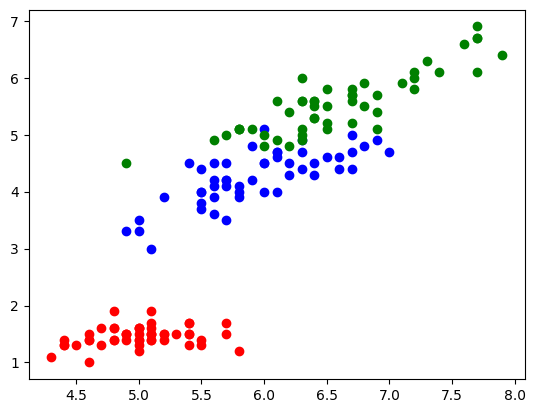

In [40]:
class1 = labels == 0
class2 = labels == 1
class3 = labels == 2
class1_features = features[class1]
class2_features = features[class2]
class3_features = features[class3]
np.mean(class1_features, axis=0), np.mean(class2_features, axis=0), np.mean(class3_features, axis=0)
plt.scatter(class1_features[:, 0], class1_features[:, 2], color="red", label="class 1")
plt.scatter(class2_features[:, 0], class2_features[:, 2], color="blue", label="class 2") 
plt.scatter(class3_features[:, 0], class3_features[:, 2], color="green", label="class 3")

mean_per_class = np.array([np.mean(class1_features, axis=0), np.mean(class2_features, axis=0), np.mean(class3_features, axis=0)])
mean_per_class

### Split the Iris data by class
This separates the examples into three groups using the labels, then computes the mean feature values for each class. Those class means are used later to choose a useful feature for classification.

In [50]:
from itertools import combinations  
difference_per_feature = []
for i in range(mean_per_class.shape[1]):
    combination = combinations(mean_per_class[:, i], 2)
    total = 0
    for pair in combination:
        total += abs(pair[0]- pair[1])
    difference_per_feature.append(total)
difference_per_feature
max_difference_index = np.argmax(difference_per_feature)
feature_with_max_difference = mean_per_class[:, max_difference_index]
mid_points = (feature_with_max_difference[0] + feature_with_max_difference[1]) / 2, (feature_with_max_difference[1] + feature_with_max_difference[2]) / 2

### Find the most useful feature
This compares the class means feature by feature, then finds the feature with the largest overall difference between classes. The midpoint values become the thresholds for prediction.

In [137]:
feature_values = features[:, max_difference_index]
thresholds = np.array(mid_points)
predictions = np.digitize(feature_values, thresholds)
np.sum(predictions == labels)/len(labels)

ValueError: operands could not be broadcast together with shapes (150,) (60000,) 

### Predict with thresholds
This uses the chosen feature and its thresholds to assign each Iris example to a predicted class, then measures the accuracy.

In [140]:
images = np.array([ex["image"] for ex in mnist_dataset["train"]])
labels = np.array([ex["label"] for ex in mnist_dataset["train"]])



### Grouping images by class
Here, the MNIST images are split into separate groups by their digit label. After that, I compute the average image for each class to see what a typical digit in each category looks like.

The idea is to compare class patterns using the mean pixel values.

In [143]:
images = np.array([images[i].reshape(28,28) for i in range(len(images))])

In [149]:
def plot_image(image_index):
    temp_image = images[image_index]
    pixels = np.empty_like(temp_image, dtype=str)
    pixels[temp_image < 64] = " "
    pixels[(temp_image >= 64) & (temp_image < 128)] = "."
    pixels[(temp_image >= 128) & (temp_image < 192)] = "*"
    pixels[temp_image >= 192] = "#"
    return "\n".join("".join(row) for row in pixels)

print(plot_image(np.random.randint(0, len(images))))


                            
                            
                            
                            
                            
                            
             *####.         
           *#######*.       
          ###########       
         #####***####       
        *####.  .###.       
       #####*   *#####      
       ####.    .#####*     
       ####      ####*      
       ####  .  .###*       
       #######.*####.       
       .############        
        .##########*        
          .###.####         
               ####         
               ####         
              ####*         
              ####          
              ####          
             *###           
              ##.           
                            
                            


### Visualizing a single MNIST image
This helper converts one image into an ASCII preview by mapping pixel intensity ranges to different characters.

- `" "` for very dark pixels
- `"."` for slightly brighter pixels
- `"*"` for medium pixels
- `"#"` for the brightest pixels

The function returns a multi-line string, and `print(...)` displays it like a small notebook output.

In [187]:
images_per_class = {}
for c, _ in enumerate(np.unique(labels)):
    images_per_class[c] = images[labels == c]
mean_value_per_pixel_per_class = {}

for c in images_per_class:
    mean_value_per_pixel_per_class[c] = np.mean(images_per_class[c], axis=0)

difference_per_pixel = {}

for c1, c2 in combinations(mean_value_per_pixel_per_class.keys(), 2):
    difference_per_pixel[(c1, c2)] = np.abs(mean_value_per_pixel_per_class[c1] - mean_value_per_pixel_per_class[c2])

Most_difference = np.argmax(difference_per_pixel[(0,1)])
Most_difference

np.int64(406)

In [220]:
idxs = np.random.choice(len(images), size=4, replace=False)
samples = images[idxs].astype(np.float32)
samples = np.array([samples[i].reshape(-1) for i in range(len(samples))])
labels[idxs]

array([3, 5, 5, 6])

### Pairwise distances between samples
This section turns a few MNIST images into flat vectors and computes the pairwise Euclidean distance matrix.

The matrix shows how similar or different each sampled image is from the others: smaller values mean more similar images, larger values mean more different images.

In [222]:
gram = samples @ samples.T
nrm = np.sum(samples*samples, axis=1, keepdims=True)
distance = np.sqrt(nrm - 2*gram + nrm.T)
distance


array([[   0.    , 3211.2935, 2940.4502, 2876.5847],
       [3211.2935,    0.    , 3489.7134, 3470.8376],
       [2940.4502, 3489.7134,    0.    , 2168.503 ],
       [2876.5847, 3470.8376, 2168.503 ,    0.    ]], dtype=float32)